<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/Densnet_exp_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/fabric_classification_dataset.zip'
extract_path = '/content/fabric_dataset_raw'

print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extracted ✅")

for root, dirs, files in os.walk(extract_path):
    print(root, "->", len(files), "files")

Mounted at /content/drive
Extracting...
Extracted ✅
/content/fabric_dataset_raw -> 0 files
/content/fabric_dataset_raw/fabric_dataset -> 1 files
/content/fabric_dataset_raw/fabric_dataset/Chiffon -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Polyester -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Linen -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Velvet -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Cotton -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Wool -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Silk -> 400 files
/content/fabric_dataset_raw/fabric_dataset/Denim -> 401 files
/content/fabric_dataset_raw/fabric_dataset/Viscose -> 400 files


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import os, random, shutil
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
def find_dataset_root(base_path):
    expected_classes = {'chiffon','cotton','denim','linen','polyester','silk','velvet','viscose','wool'}
    for root, dirs, files in os.walk(base_path):
        if expected_classes.issubset(set(d.lower() for d in dirs)):
            return root
    return base_path

dataset_root = find_dataset_root(extract_path)
print("Dataset root:", dataset_root)

classes = sorted([d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))])
print("Classes:", classes)

for c in classes:
    count = len(os.listdir(os.path.join(dataset_root, c)))
    print(f"{c}: {count} original images")

Dataset root: /content/fabric_dataset_raw/fabric_dataset
Classes: ['Chiffon', 'Cotton', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']
Chiffon: 400 original images
Cotton: 400 original images
Denim: 401 original images
Linen: 400 original images
Polyester: 400 original images
Silk: 400 original images
Velvet: 400 original images
Viscose: 400 original images
Wool: 400 original images


In [ ]:
split_base = '/content/split_dataset'
if os.path.exists(split_base):
    shutil.rmtree(split_base)

for split in ['train', 'val', 'test']:
    for c in classes:
        os.makedirs(f'{split_base}/{split}/{c}', exist_ok=True)

for c in classes:
    src_folder = os.path.join(dataset_root, c)
    imgs = [f for f in os.listdir(src_folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    random.shuffle(imgs)

    n = len(imgs)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)

    for i, img in enumerate(imgs):
        src = os.path.join(src_folder, img)
        if i < train_end:
            dst = f'{split_base}/train/{c}/{img}'
        elif i < val_end:
            dst = f'{split_base}/val/{c}/{img}'
        else:
            dst = f'{split_base}/test/{c}/{img}'
        os.symlink(src, dst)

train_dir = f'{split_base}/train'
val_dir = f'{split_base}/val'
test_dir = f'{split_base}/test'

for split in ['train', 'val', 'test']:
    total = sum(len(os.listdir(f'{split_base}/{split}/{c}')) for c in classes)
    print(f"{split}: {total} images")

train: 2520 images
val: 540 images
test: 541 images


In [ ]:
class FabricDataGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size=32, target_size=(224, 224), shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_paths = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        batch_x, batch_y = [], []
        for path, label in zip(batch_paths, batch_labels):
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.target_size)
            batch_x.append(img)
            batch_y.append(label)

        batch_x = np.array(batch_x, dtype=np.float32)
        batch_x = tf.keras.applications.densenet.preprocess_input(batch_x)
        return batch_x, np.array(batch_y)

    def on_epoch_end(self):
        if self.shuffle:
            combined = list(zip(self.image_paths, self.labels))
            random.shuffle(combined)
            self.image_paths, self.labels = zip(*combined)
            self.image_paths, self.labels = list(self.image_paths), list(self.labels)

print("✅ No-augmentation generator ready")

✅ No-augmentation generator ready


In [ ]:
class_indices = {cls: i for i, cls in enumerate(classes)}

def build_paths_labels(folder):
    paths, labels = [], []
    for cls in classes:
        cls_dir = os.path.join(folder, cls)
        for img_name in os.listdir(cls_dir):
            paths.append(os.path.join(cls_dir, img_name))
            labels.append(class_indices[cls])
    return paths, labels

train_paths, train_labels = build_paths_labels(train_dir)
val_paths, val_labels = build_paths_labels(val_dir)
test_paths, test_labels = build_paths_labels(test_dir)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

train_gen = FabricDataGenerator(train_paths, train_labels, batch_size=32, shuffle=True)
val_gen = FabricDataGenerator(val_paths, val_labels, batch_size=32, shuffle=False)
test_gen = FabricDataGenerator(test_paths, test_labels, batch_size=32, shuffle=False)

Train: 2520 | Val: 540 | Test: 541


In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.unique(train_labels), y=train_labels
)
class_weights = dict(enumerate(class_weights_array))

# Polyester: previously acted as a "catch-all" class (high recall, low precision)
# Reduce its weight so the model doesn't over-predict it as a default guess
polyester_idx = class_indices['Polyester']
class_weights[polyester_idx] *= 0.5

# Wool: samples are inconsistent (fun-fur/tweed/smooth mixed) - cap weight,
# don't let the model over-emphasize learning from noisy examples
wool_idx = class_indices['Wool']
class_weights[wool_idx] = min(class_weights[wool_idx], 1.0)

# Viscose: also tended to act as a secondary catch-all
viscose_idx = class_indices['Viscose']
class_weights[viscose_idx] *= 0.6

# ⚠️ NEW: Silk was confused with Chiffon/Polyester/Viscose (all smooth/sheen
# fabrics). Slightly boost Silk's weight so the model pays more attention
# to its specific distinguishing features instead of grouping it with
# other smooth fabrics.
silk_idx = class_indices['Silk']
class_weights[silk_idx] *= 1.3

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(0.5), 5: np.float64(1.3), 6: np.float64(1.0), 7: np.float64(0.6), 8: np.float64(1.0)}


In [ ]:
base_model = tf.keras.applications.DenseNet121(
    include_top=False, weights="imagenet", input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(classes), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,307,337 (27.88 MB)

 Trainable params: 267,273 (1.02 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("/content/best_fabric_model.keras",
                              monitor="val_loss", save_best_only=True, verbose=1)

In [ ]:
print("\n--- Stage 1: Training the new layers only ---")
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history1 = model.fit(
    train_gen, validation_data=val_gen, epochs=12,
    callbacks=[reduce_lr, early_stopping, checkpoint],
    class_weight=class_weights
)


--- Stage 1: Training the new layers only ---
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.4522 - loss: 1.6879 
Epoch 1: val_loss improved from None to 0.83051, saving model to /content/best_fabric_model.keras

Epoch 1: finished saving model to /content/best_fabric_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 1753s 22s/step - accuracy: 0.5798 - loss: 1.2264 - val_accuracy: 0.7815 - val_loss: 0.8305 - learning_rate: 0.0010
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.7118 - loss: 0.7568 
Epoch 2: val_loss improved from 0.83051 to 0.63641, saving model to /content/best_fabric_model.keras

Epoch 2: finished saving model to /content/best_fabric_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 1682s 21s/step - accuracy: 0.7250 - loss: 0.7163 - val_accuracy: 0.8204 - val_loss: 0.6364 - learning_rate: 0.0010
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.7663 - loss: 0.6217 
Epoch 3: val_loss improved from 0.63641 to 0.54769, saving model to /content/be

In [ ]:
print("\n--- Stage 2: Fine-tuning top layers ---")
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history2 = model.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[reduce_lr, early_stopping, checkpoint],
    class_weight=class_weights
)

print("✅ Training completed!")


--- Stage 2: Fine-tuning top layers ---
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.8105 - loss: 0.4695 
Epoch 1: val_loss did not improve from 0.31352
79/79 ━━━━━━━━━━━━━━━━━━━━ 2127s 26s/step - accuracy: 0.8131 - loss: 0.4625 - val_accuracy: 0.8889 - val_loss: 0.3765 - learning_rate: 1.0000e-05
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8309 - loss: 0.4347 
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_loss did not improve from 0.31352
79/79 ━━━━━━━━━━━━━━━━━━━━ 1732s 22s/step - accuracy: 0.8325 - loss: 0.4473 - val_accuracy: 0.8907 - val_loss: 0.3773 - learning_rate: 1.0000e-05
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8255 - loss: 0.4352 
Epoch 3: val_loss did not improve from 0.31352
79/79 ━━━━━━━━━━━━━━━━━━━━ 1896s 24s/step - accuracy: 0.8397 - loss: 0.4215 - val_accuracy: 0.8981 - val_loss: 0.3729 - learning_rate: 5.0000e-06
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/ste

17/17 ━━━━━━━━━━━━━━━━━━━━ 298s 15s/step
Test Accuracy: 86.51%

              precision    recall  f1-score   support

     Chiffon       0.95      0.90      0.92        60
      Cotton       0.83      0.88      0.85        60
       Denim       0.89      0.84      0.86        61
       Linen       0.85      0.92      0.88        60
   Polyester       0.75      0.68      0.71        60
        Silk       0.74      0.80      0.77        60
      Velvet       0.87      1.00      0.93        60
     Viscose       0.94      0.80      0.86        60
        Wool       1.00      0.97      0.98        60

    accuracy                           0.87       541
   macro avg       0.87      0.87      0.86       541
weighted avg       0.87      0.87      0.86       541



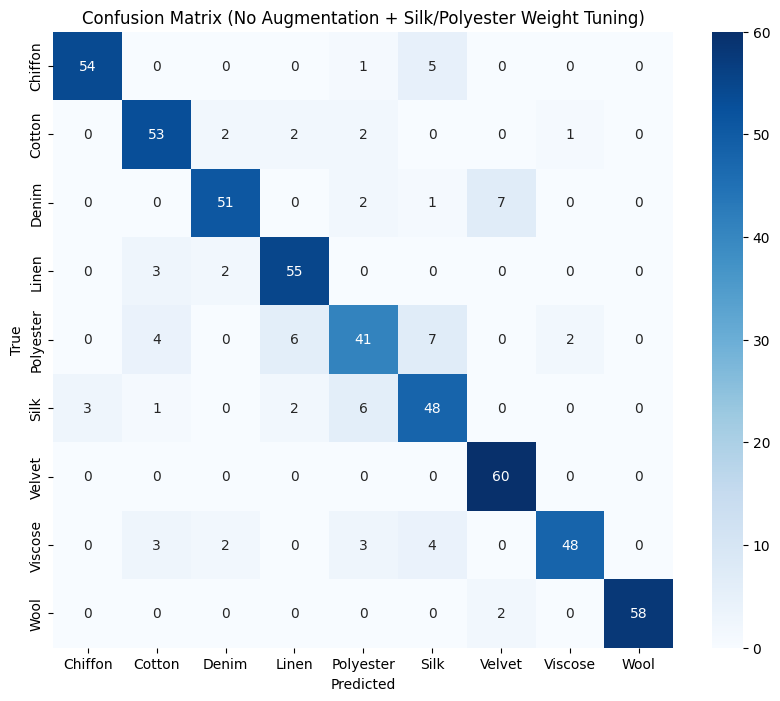

Chiffon: 54/60 (90.0%) | Confused with: [('Silk', np.int64(5)), ('Polyester', np.int64(1))]
Cotton: 53/60 (88.3%) | Confused with: [('Denim', np.int64(2)), ('Linen', np.int64(2)), ('Polyester', np.int64(2)), ('Viscose', np.int64(1))]
Denim: 51/61 (83.6%) | Confused with: [('Velvet', np.int64(7)), ('Polyester', np.int64(2)), ('Silk', np.int64(1))]
Linen: 55/60 (91.7%) | Confused with: [('Cotton', np.int64(3)), ('Denim', np.int64(2))]
Polyester: 41/60 (68.3%) | Confused with: [('Silk', np.int64(7)), ('Linen', np.int64(6)), ('Cotton', np.int64(4)), ('Viscose', np.int64(2))]
Silk: 48/60 (80.0%) | Confused with: [('Polyester', np.int64(6)), ('Chiffon', np.int64(3)), ('Linen', np.int64(2)), ('Cotton', np.int64(1))]
Velvet: 60/60 (100.0%) | Confused with: []
Viscose: 48/60 (80.0%) | Confused with: [('Silk', np.int64(4)), ('Cotton', np.int64(3)), ('Polyester', np.int64(3)), ('Denim', np.int64(2))]
Wool: 58/60 (96.7%) | Confused with: [('Velvet', np.int64(2))]


In [ ]:
best_model = tf.keras.models.load_model("/content/best_fabric_model.keras")

y_pred_probs = best_model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels[:len(y_pred)])

test_acc = np.mean(y_pred == y_true)
print(f"Test Accuracy: {test_acc*100:.2f}%\n")

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (No Augmentation + Silk/Polyester Weight Tuning)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()

for i, cls in enumerate(classes):
    total = cm[i].sum()
    correct = cm[i][i]
    confused_with = [(classes[j], cm[i][j]) for j in range(len(classes)) if j != i and cm[i][j] > 0]
    confused_with.sort(key=lambda x: -x[1])
    print(f"{cls}: {correct}/{total} ({correct/total*100:.1f}%) | Confused with: {confused_with}")

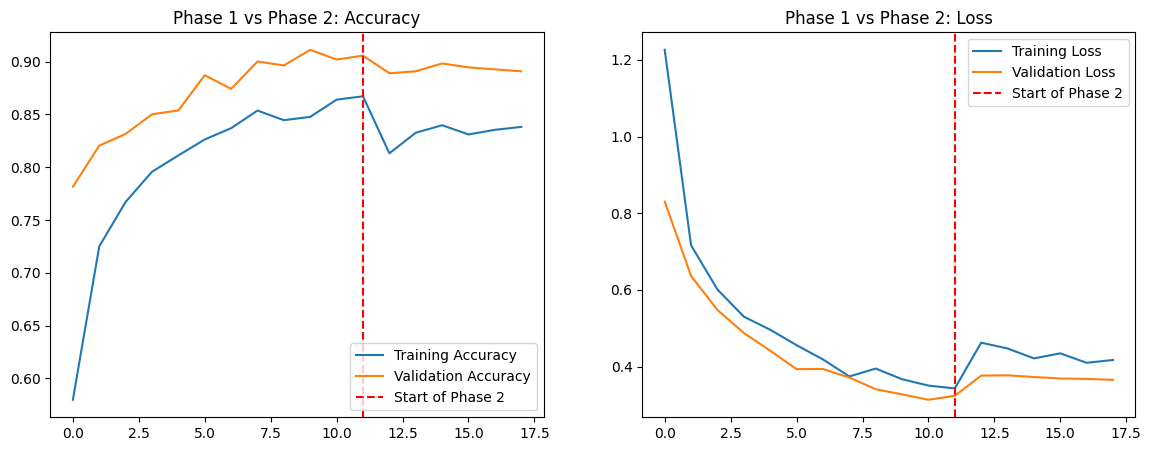

In [ ]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history1.history['accuracy'])-1, color='r', linestyle='--', label='Start of Phase 2')
plt.title('Phase 1 vs Phase 2: Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=len(history1.history['loss'])-1, color='r', linestyle='--', label='Start of Phase 2')
plt.title('Phase 1 vs Phase 2: Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
drive_save_path = '/content/drive/MyDrive/fabric_classifier_model'
os.makedirs(drive_save_path, exist_ok=True)

shutil.copy("/content/best_fabric_model.keras", f"{drive_save_path}/fabric_classifier.keras")

import json
class_info = {"classes": classes, "input_size": [224, 224], "preprocessing": "densenet"}
with open(f'{drive_save_path}/class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print(f"✅ Model saved to Google Drive: {drive_save_path}")

✅ Model saved to Google Drive: /content/drive/MyDrive/fabric_classifier_model


📸 upload image...


Saving denim.jfif to denim.jfif


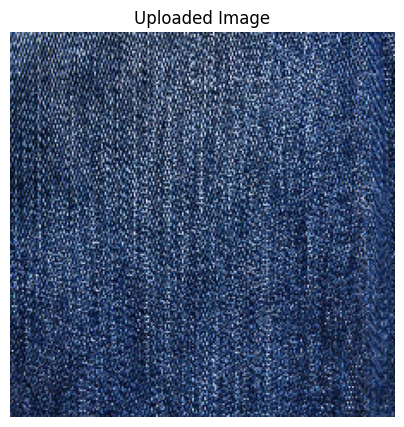

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Predicted: Denim (99.99%)
Top-3:
  Denim: 99.99%
  Velvet: 0.01%
  Silk: 0.00%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸 upload image...


Saving IMG-20260719-WA0082.jpg to IMG-20260719-WA0082.jpg


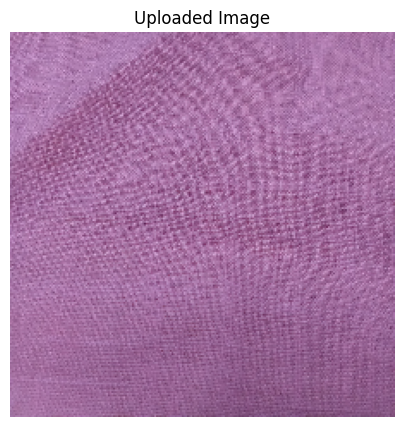

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step

Predicted: Cotton (97.19%)
Top-3:
  Cotton: 97.19%
  Viscose: 1.12%
  Linen: 0.80%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸 upload image...


Saving Cotton6.jpg to Cotton6.jpg


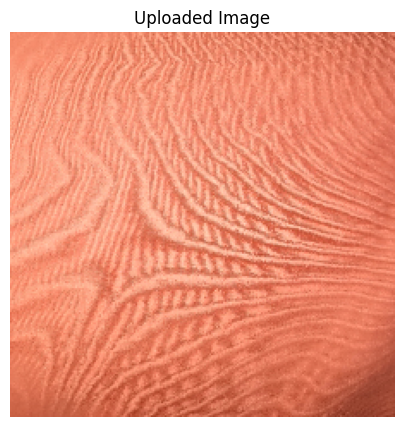

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

Predicted: Viscose (38.16%)
Top-3:
  Viscose: 38.16%
  Cotton: 31.43%
  Linen: 29.74%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸 upload image...


Saving poly.jpg to poly.jpg


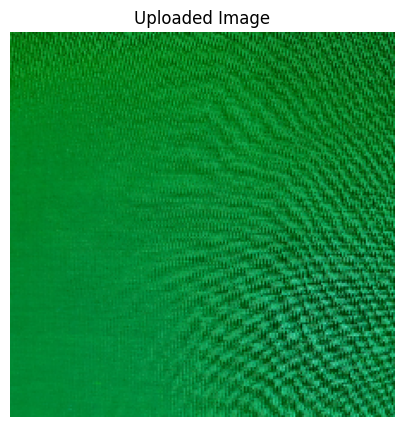

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step

Predicted: Polyester (86.06%)
Top-3:
  Polyester: 86.06%
  Chiffon: 6.91%
  Silk: 3.91%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸 upload image...


Saving wool (2).jpg to wool (2).jpg


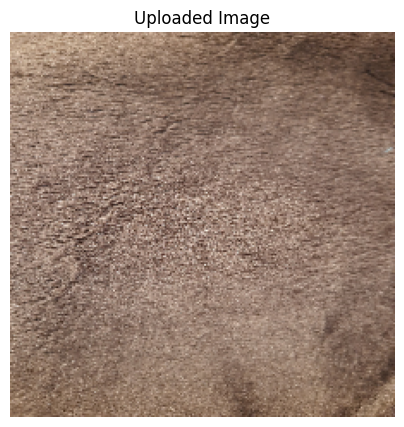

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

Predicted: Wool (99.77%)
Top-3:
  Wool: 99.77%
  Velvet: 0.16%
  Denim: 0.05%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸 upload image...


Saving IMG-20260719-WA0084.jpg to IMG-20260719-WA0084.jpg


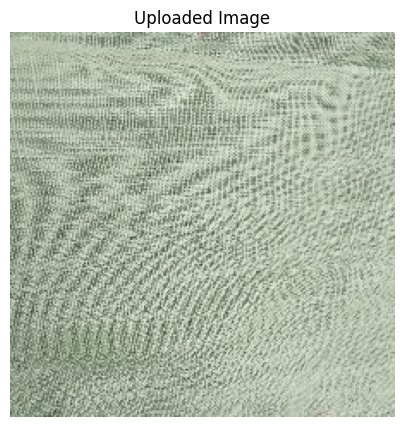

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step

Predicted: Linen (88.26%)
Top-3:
  Linen: 88.26%
  Polyester: 10.13%
  Cotton: 0.53%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")

📸 upload image...


Saving IMG-20260719-WA0087.jpg to IMG-20260719-WA0087 (1).jpg


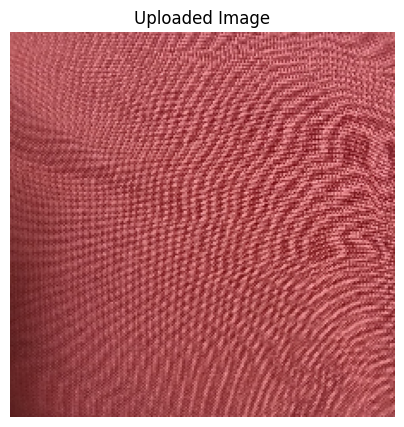

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step

Predicted: Viscose (88.46%)
Top-3:
  Viscose: 88.46%
  Cotton: 4.14%
  Polyester: 3.68%


In [ ]:
from google.colab import files

print("📸 upload image...")
uploaded = files.upload()

for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    predictions = best_model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = classes[predicted_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted: {predicted_class} ({confidence:.2f}%)")
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    print("Top-3:")
    for idx in top3_idx:
        print(f"  {classes[idx]}: {predictions[0][idx]*100:.2f}%")